# Function Approximation Using Multilayer Perceptron (MLP)

**Student:** Ayshan Gambarli



In [ ]:
import random
import csv
N = 500
alphas = [0, 0.01, 0.03, 0.05]
def f(x1, x2):
  return 5*x1**2 + 7*x1*x2 - x2**2 - x1 + x2 + 5
dataset = []
for i in range(1, N + 1):
  x1 = round(random.uniform(-1, 1), 10)
  x2 = round(random.uniform(-1, 1), 10)
  fx = round(f(x1, x2), 10)
  delta = round(random.uniform(-1, 1), 10)
  y_alpha = []
  for alpha in alphas:
    y = round(fx * (1 + alpha * delta), 10)
    y_alpha.append(y)
  dataset.append([i, x1, x2, fx, delta, *y_alpha])
header = ["i", "x1", "x2", "f(x)", "delta", "y(alpha=0)", "y(alpha=0.01)", "y(alpha=0.03)", "y(alpha=0.05)"]
with open("dataset.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(header)
    writer.writerows(dataset)
print("Dataset.csv yaradıldı.")
train_data = dataset[:400]
test_data = dataset[400:]
print("Train size:", len(train_data))
print("Test size:", len(test_data))
with open("train.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(header)
    writer.writerows(train_data)
with open("test.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(header)
    writer.writerows(test_data)
print("Train və Test faylları yaradıldı.")

Dataset.csv yaradıldı.
Train size: 400
Test size: 100
Train və Test faylları yaradıldı.


In [ ]:
input_size = 2
hidden_size = 5
output_size = 1
print("Input neurons:", input_size)
print("Hidden neurons:", hidden_size)
print("Output neurons:", output_size)

Input neurons: 2
Hidden neurons: 5
Output neurons: 1


In [ ]:
weights_input_hidden = []
for i in range(input_size):
    row = []
    for j in range(hidden_size):
        weight = round(random.uniform(-1,1),10)
        row.append(weight)
    weights_input_hidden.append(row)

In [ ]:
weights_hidden_output = []
for i in range(hidden_size):
    weight = round(random.uniform(-1,1),10)
    weights_hidden_output.append(weight)

In [ ]:
print("Input -> Hidden weights")
for row in weights_input_hidden:
    print(row)
print()
print("Hidden -> Output weights")
print(weights_hidden_output)

Input -> Hidden weights
[0.5480647709, -0.0235354291, 0.175475653, 0.3599092028, -0.8629326415]
[0.4902280994, -0.7723190682, -0.5823114375, -0.3056687145, 0.5430930624]

Hidden -> Output weights
[0.3891551501, 0.2892804163, 0.6177931756, -0.5425297577, -0.4867030315]


In [ ]:
bias_hidden = []
for i in range(hidden_size):
    bias_hidden.append(round(random.uniform(-1,1),10))
bias_output = round(random.uniform(-1,1),10)

In [ ]:
print("Hidden bias:")
print(bias_hidden)
print()
print("Output bias:")
print(bias_output)

Hidden bias:
[-0.1357094863, -0.0840504457, -0.6376789006, 0.6173746154, -0.9994602535]

Output bias:
-0.5785695614


In [ ]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
X_train = [[row[1], row[2]] for row in train_data]
y_train = [row[5] for row in train_data]
X_test = [[row[1], row[2]] for row in test_data]
y_test = [row[5] for row in test_data]

In [ ]:
model = Sequential()
model.add(Dense(5, input_dim=2, activation="sigmoid"))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = "adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
print(type(X_train))
print(type(y_train))
print(len(X_train))
print(len(y_train))
print(X_train[:3])
print(y_train[:3])

<class 'list'>
<class 'list'>
400
400
[[0.6180150131, 0.0694530585], [0.7471540198, -0.2263596668], [-0.3457265248, -0.9852305396]]
[6.6567883302, 5.5825645164, 6.3717932329]


In [ ]:
import numpy as np

In [ ]:
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [ ]:
print(type(X_train))
print(X_train.shape)
print(type(y_train))
print(y_train.shape)

<class 'numpy.ndarray'>
(400, 2)
<class 'numpy.ndarray'>
(400,)


In [ ]:
history = model.fit(X_train, y_train, epochs=2000, verbose=1)

Epoch 1/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1742 - mae: 0.2916
Epoch 2/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1742 - mae: 0.2915 
Epoch 3/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1741 - mae: 0.2915 
Epoch 4/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1740 - mae: 0.2913
Epoch 5/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1740 - mae: 0.2909
Epoch 6/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1739 - mae: 0.2908
Epoch 7/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1740 - mae: 0.2916
Epoch 8/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1739 - mae: 0.2916 
Epoch 9/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1736 - mae: 0.2909
Epoch 10/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1737 - mae: 0.2921
Epoch 11/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1737 - mae: 0.2917  
Epoch 12/2000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1735 - mae: 0.2918 
Epoch 13/2000


In [ ]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae )

Test MSE: 0.40368136763572693
Test MAE: 0.405224084854126


In [ ]:
train_loss, train_mae = model.evaluate(
    X_train,
    y_train,
    verbose=0
)
print("Train MSE:", train_loss)
print("Train MAE:", train_mae)

Train MSE: 0.17409303784370422
Train MAE: 0.2916554808616638


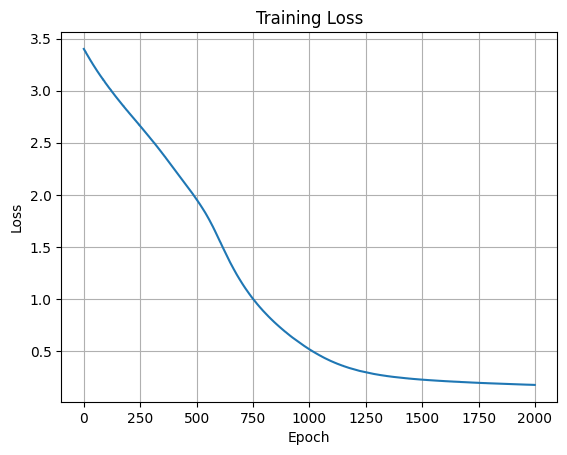

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

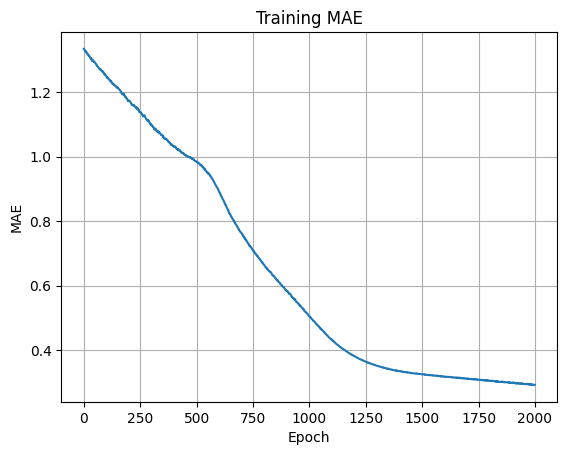

In [ ]:
plt.plot(history.history["mae"])
plt.title("Training MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

In [ ]:
predictions = model.predict(X_test)
print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[ 4.057478 ]
 [ 5.467737 ]
 [ 5.2258005]
 [ 4.9979877]
 [11.530327 ]
 [ 1.546966 ]
 [ 5.9407663]
 [ 5.540716 ]
 [ 5.331006 ]
 [ 5.2607083]]


In [ ]:
for i in  range(10):
  print("Real:", y_test[i], "Prediction:", predictions[i][0])

Real: 3.7994053 Prediction: 4.057478
Real: 4.8100834 Prediction: 5.467737
Real: 3.451102 Prediction: 5.2258005
Real: 4.9374614 Prediction: 4.9979877
Real: 11.381665 Prediction: 11.530327
Real: 1.6406311 Prediction: 1.546966
Real: 6.464018 Prediction: 5.9407663
Real: 6.0235825 Prediction: 5.540716
Real: 5.002951 Prediction: 5.331006
Real: 5.2000227 Prediction: 5.2607083


In [ ]:
for i in range(10):
  error = abs(y_test[i] - predictions[i][0])
  print(error)

0.2580726
0.6576538
1.7746985
0.06052637
0.14866161
0.09366512
0.52325153
0.4828663
0.3280549
0.060685635


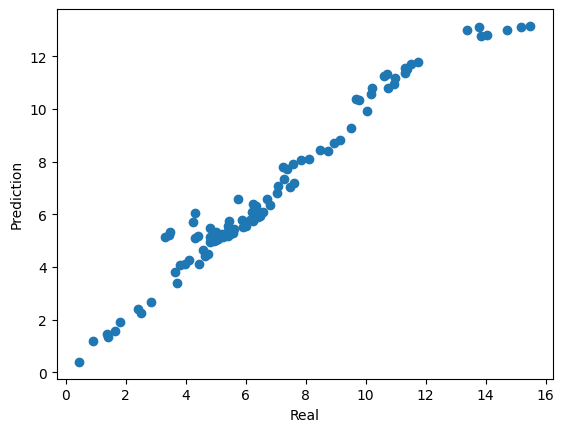

In [ ]:
plt.scatter(y_test, predictions)
plt.xlabel("Real")
plt.ylabel("Prediction")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
train_predictions = model.predict(X_train)
train_mape = mean_absolute_percentage_error(
    y_train,
    train_predictions
)
print("Train MAPE:", train_mape * 100, "%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Train MAPE: 5.7478152215480804 %


In [ ]:
test_predictions = model.predict(X_test)
test_mape = mean_absolute_percentage_error(
    y_test,
    test_predictions
)
print("Test MAPE:", test_mape * 100, "%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test MAPE: 7.171175628900528 %
